In [14]:
!pip install biopython pandas matplotlib
!pip install -q streamlit
!npm install -q -g localtunnel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 58.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 105.9 MB/s eta 0:00:00
⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋
added 22 packages in 2s
⠋
⠋3 packages are looking for funding
⠋  run `npm fund` for details
⠋

=== TOP 3 SEKUENS TERBAIK (BERDASARKAN SKOR MULTIVARIAT) ===
1. ID: lcl|MH450301.2_cds_AXB26592.2_1
   -> Skor Komposit: 56.39
   -> GC Content   : 46.47%
   -> Est. Tm      : 83.89 °C
   -> Rasio CpG    : 0.424 (Depletion Marker)
   -> Panjang      : 10179 bp

2. ID: lcl|KP772252.1_cds_AKC89102.1_1
   -> Skor Komposit: 56.31
   -> GC Content   : 46.38%
   -> Est. Tm      : 83.85 °C
   -> Rasio CpG    : 0.422 (Depletion Marker)
   -> Panjang      : 10179 bp

3. ID: lcl|KR919821.1_cds_AMN88557.1_1
   -> Skor Komposit: 56.30
   -> GC Content   : 46.42%
   -> Est. Tm      : 83.87 °C
   -> Rasio CpG    : 0.419 (Depletion Marker)
   -> Panjang      : 10179 bp

Grafik multi-panel disimpan sebagai 'grafik_analisis_multivariat.png'
Data tabular disimpan sebagai 'hasil_analisis_dengue_advanced.csv'


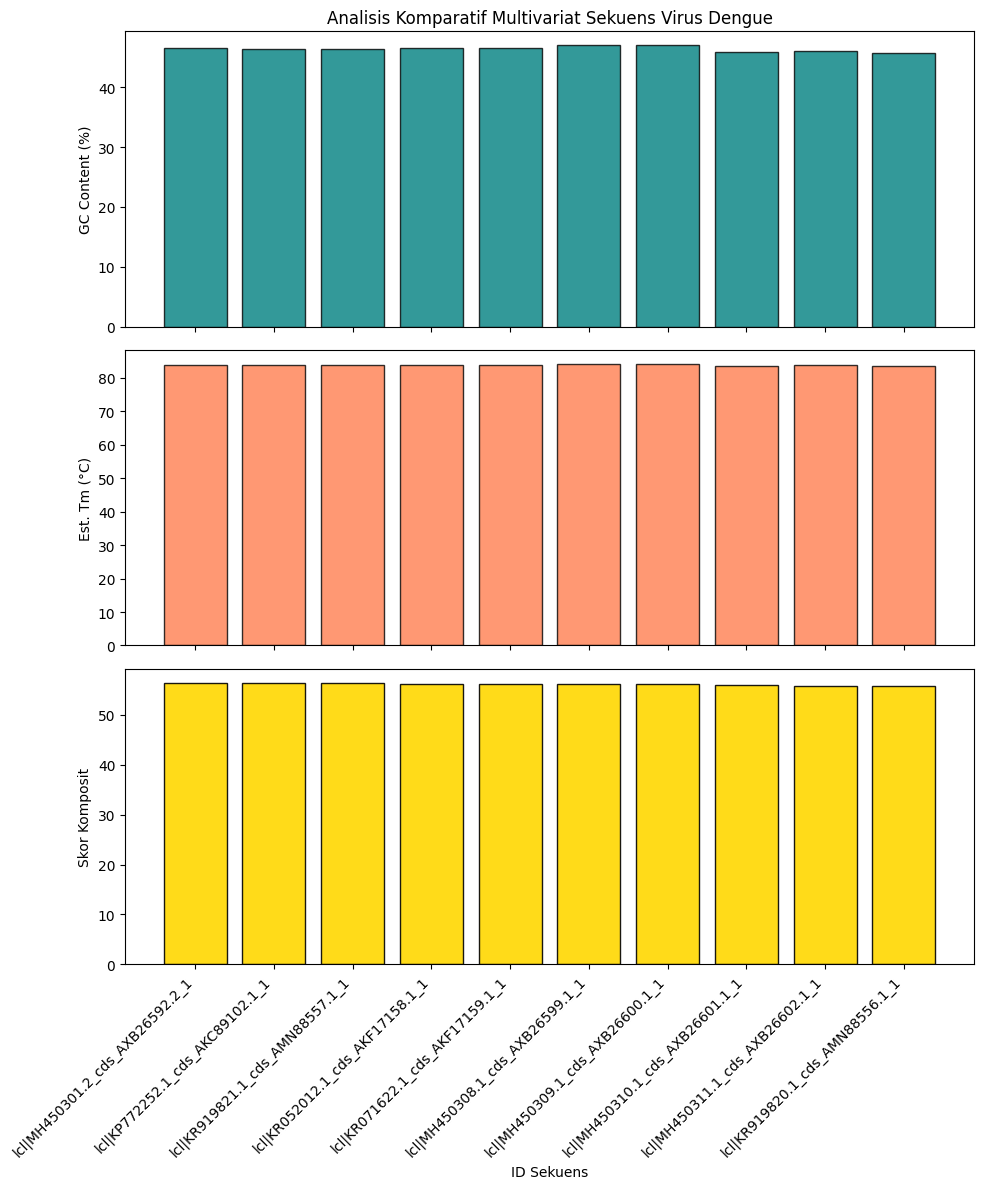

In [12]:
import csv
import math
import matplotlib.pyplot as plt

def read_fasta(file_path):
    sequences = []
    current_header = None
    current_seq = []

    with open(file_path, 'r') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            if line.startswith('>'):
                if current_header:
                    sequences.append((current_header, "".join(current_seq)))
                current_header = line[1:]
                current_seq = []
            else:
                current_seq.append(line.upper())
        if current_header:
            sequences.append((current_header, "".join(current_seq)))
    return sequences

def analyze_sequence_properties(sequence):
    """
    Menghitung parameter mutakhir: Frekuensi, GC%, Tm, dan Frekuensi CpG.
    """
    # 1. Frekuensi Nukleotida Tunggal
    counts = {'A': 0, 'C': 0, 'G': 0, 'T': 0}
    for nuc in sequence:
        if nuc in counts:
            counts[nuc] += 1

    total_len = sum(counts.values())
    if total_len == 0:
        return None

    gc_content = ((counts['G'] + counts['C']) / total_len) * 100

    # 2. Estimasi Melting Temperature (Tm) Global
    # Menggunakan rumus Wallace (untuk sekuens pendek) atau rumus standar garam keras untuk sekuens panjang:
    # Tm = 64.9 + 41*(G+C-16.4)/(A+T+G+C)
    g_c = counts['G'] + counts['C']
    tm = 64.9 + 41 * (g_c - 16.4) / total_len if total_len > 0 else 0

    # 3. Menghitung Frekuensi Dinukleotida CpG (Sitosin diikuti Guanin)
    # Penting untuk virologi (immune evasion)
    cpg_count = sequence.count('CG')
    # Ekspektasi CpG jika acak = (Jumlah C * Jumlah G) / Total
    expected_cpg = (counts['C'] * counts['G']) / total_len if total_len > 0 else 0
    # Rasio Odds CpG (Observed vs Expected)
    cpg_ratio = cpg_count / expected_cpg if expected_cpg > 0 else 0

    # 4. Perhitungan Skor Komposit untuk menentukan Top 3 (Kombinasi Multivariat)
    # Menormalisasi nilai agar rentangnya seimbang (Bobot: 40% GC, 40% Tm, 20% CpG Ratio)
    composite_score = (gc_content * 0.4) + (tm * 0.4) + (cpg_ratio * 10) # dikali 10 agar skalanya setara

    return {
        'Counts': counts,
        'GC_Content': gc_content,
        'Tm': tm,
        'CpG_Ratio': cpg_ratio,
        'Composite_Score': composite_score
    }

def run_advanced_pipeline(file_path):
    raw_data = read_fasta(file_path)
    analyzed_data = []

    for header, seq in raw_data:
        seq_id = header.split()[0]
        props = analyze_sequence_properties(seq)

        if props:
            analyzed_data.append({
                'ID': seq_id,
                'Header': header,
                'Length': len(seq),
                **props
            })

    # Mengurutkan berdasarkan SKOR KOMPOSIT (Multivariat)
    analyzed_data.sort(key=lambda x: x['Composite_Score'], reverse=True)

    # Menampilkan 3 sekuens terbaik berdasarkan kriteria kompleks
    print("================================================================")
    print("=== TOP 3 SEKUENS TERBAIK (BERDASARKAN SKOR MULTIVARIAT) ===")
    print("================================================================")
    for i, data in enumerate(analyzed_data[:3], 1):
        print(f"{i}. ID: {data['ID']}")
        print(f"   -> Skor Komposit: {data['Composite_Score']:.2f}")
        print(f"   -> GC Content   : {data['GC_Content']:.2f}%")
        print(f"   -> Est. Tm      : {data['Tm']:.2f} °C")
        print(f"   -> Rasio CpG    : {data['CpG_Ratio']:.3f} (Depletion Marker)")
        print(f"   -> Panjang      : {data['Length']} bp\n")

    # Menuliskan ke CSV
    csv_file = 'hasil_analisis_dengue_advanced.csv'
    with open(csv_file, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(['ID', 'Length', 'Count_A', 'Count_C', 'Count_G', 'Count_T', 'GC_Persen', 'Tm_Celcius', 'CpG_Ratio', 'Composite_Score'])
        for d in analyzed_data:
            writer.writerow([
                d['ID'], d['Length'], d['Counts']['A'], d['Counts']['C'], d['Counts']['G'], d['Counts']['T'],
                round(d['GC_Content'], 2), round(d['Tm'], 2), round(d['CpG_Ratio'], 3), round(d['Composite_Score'], 2)
            ])

    # Visualisasi Multi-Panel (Biar Grafik Kamu Terlihat Sangat Profesional!)
    ids = [d['ID'] for d in analyzed_data]
    gc_vals = [d['GC_Content'] for d in analyzed_data]
    tm_vals = [d['Tm'] for d in analyzed_data]
    score_vals = [d['Composite_Score'] for d in analyzed_data]

    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

    # Plot 1: GC Content
    ax1.bar(ids, gc_vals, color='teal', alpha=0.8, edgecolor='black')
    ax1.set_ylabel('GC Content (%)')
    ax1.set_title('Analisis Komparatif Multivariat Sekuens Virus Dengue')

    # Plot 2: Melting Temperature
    ax2.bar(ids, tm_vals, color='coral', alpha=0.8, edgecolor='black')
    ax2.set_ylabel('Est. Tm (°C)')

    # Plot 3: Composite Score (Penentu Top 3)
    bars3 = ax3.bar(ids, score_vals, color='gold', alpha=0.9, edgecolor='black')
    ax3.set_ylabel('Skor Komposit')
    ax3.set_xlabel('ID Sekuens')

    # Highlight 3 terbaik di grafik skor dengan memutar label atau teks
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('grafik_analisis_multivariat.png', dpi=300)
    print(f"Grafik multi-panel disimpan sebagai 'grafik_analisis_multivariat.png'")
    print(f"Data tabular disimpan sebagai '{csv_file}'")
    plt.show()

if __name__ == "__main__":
    run_advanced_pipeline('dengue.fasta')